#Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
!git clone https://github.com/OPIM5512-JSB21017/myscrapers-jsb21017.git
%cd myscrapers-jsb21017

Cloning into 'myscrapers-jsb21017'...
remote: Enumerating objects: 544, done.
remote: Counting objects: 100% (544/544), done.
remote: Compressing objects: 100% (340/340), done.
remote: Total 544 (delta 190), reused 383 (delta 120), pack-reused 0 (from 0)
Receiving objects: 100% (544/544), 589.91 KiB | 3.71 MiB/s, done.
Resolving deltas: 100% (190/190), done.
/content/myscrapers-jsb21017


#Load Metrics History

In [3]:
# This file was created in the modeling notebook.
# It tracks how model performance changes each time you rerun training.

history_path = "artifacts/history/model_metrics_history.csv"

history = pd.read_csv(history_path)
history["run_ts"] = pd.to_datetime(history["run_ts"], errors="coerce")
history = history.sort_values("run_ts").reset_index(drop=True)

print("History shape:", history.shape)
history

History shape: (1, 9)


,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
0,2026-04-04 13:56:41.789507,464,394,70,5613.042967,14678.35795,0.452199,-3624.109393,"{'model__max_depth': None, 'model__min_samples..."


#Model Accuracy Over Time

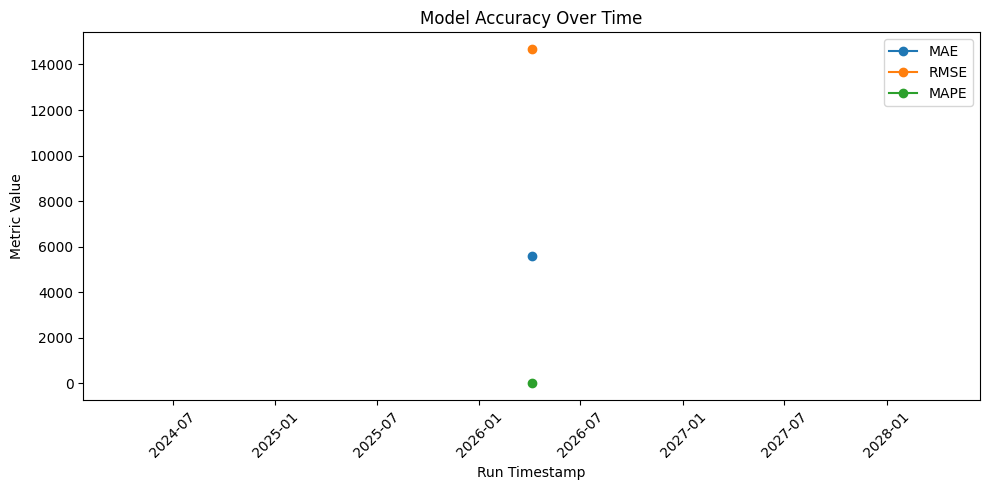

In [4]:
# This shows how your error metrics change as the dataset grows.

plt.figure(figsize=(10, 5))
plt.plot(history["run_ts"], history["mae"], marker="o", label="MAE")
plt.plot(history["run_ts"], history["rmse"], marker="o", label="RMSE")
plt.plot(history["run_ts"], history["mape"], marker="o", label="MAPE")
plt.legend()
plt.title("Model Accuracy Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Bias Over Time

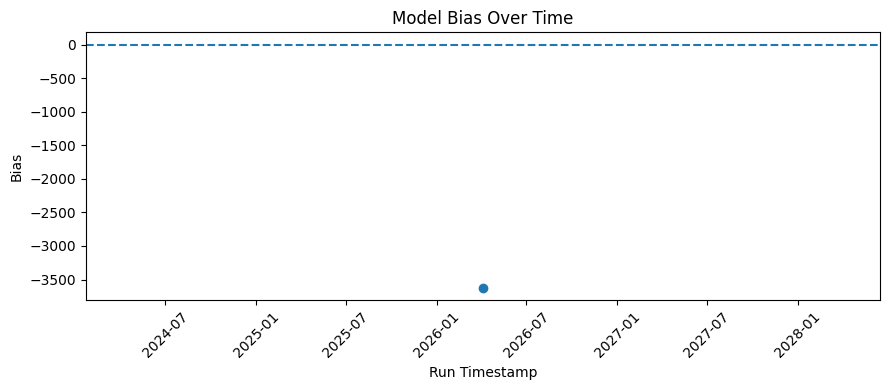

In [5]:
# Bias tells you whether the model tends to overpredict or underpredict.

plt.figure(figsize=(9, 4))
plt.plot(history["run_ts"], history["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Model Bias Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Bias")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Dataset Growth Over Time

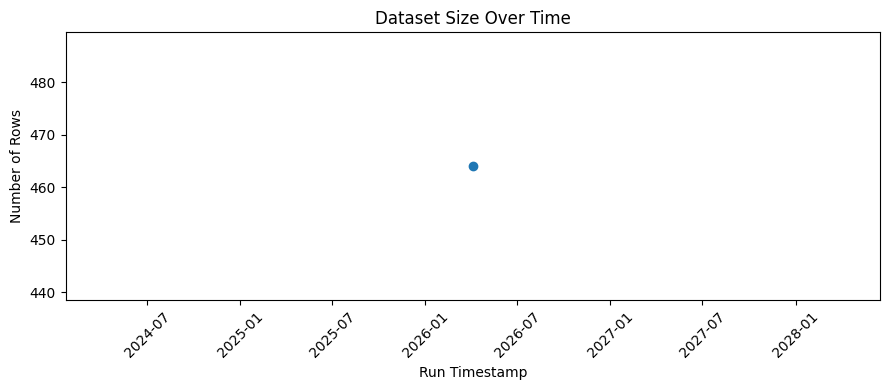

In [7]:
# This shows how the size of the modeling dataset changes.

plt.figure(figsize=(9, 4))
plt.plot(history["run_ts"], history["n_rows"], marker="o")
plt.title("Dataset Size Over Time")
plt.xlabel("Run Timestamp")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Latest Run Summary

In [8]:
latest_run = history.iloc[-1:].copy()
latest_run

,run_ts,n_rows,train_valid_rows,test_rows,mae,rmse,mape,bias,best_params
0,2026-04-04 13:56:41.789507,464,394,70,5613.042967,14678.35795,0.452199,-3624.109393,"{'model__max_depth': None, 'model__min_samples..."


#Load Permutation Importance

In [9]:
importance_path = "artifacts/importance/permutation_importance.csv"

importance = pd.read_csv(importance_path)
importance.head(15)

,feature,importance_mean,importance_std
0,num__mileage,0.353352,0.034839
1,num__year,0.057179,0.018175
2,num__mileage_per_year,0.049459,0.011320
3,num__vehicle_age,0.044966,0.015449
4,cat__city_New Haven,0.023599,0.012721
5,cat__seller_type_private seller,0.018181,0.015692
6,cat__seller_type_dealer,0.017643,0.017058
7,cat__condition_Used,0.005036,0.002198
8,cat__body_type_truck,0.004472,0.003153
9,cat__city_North Haven,0.004203,0.000792


#Plot Top Importance Features

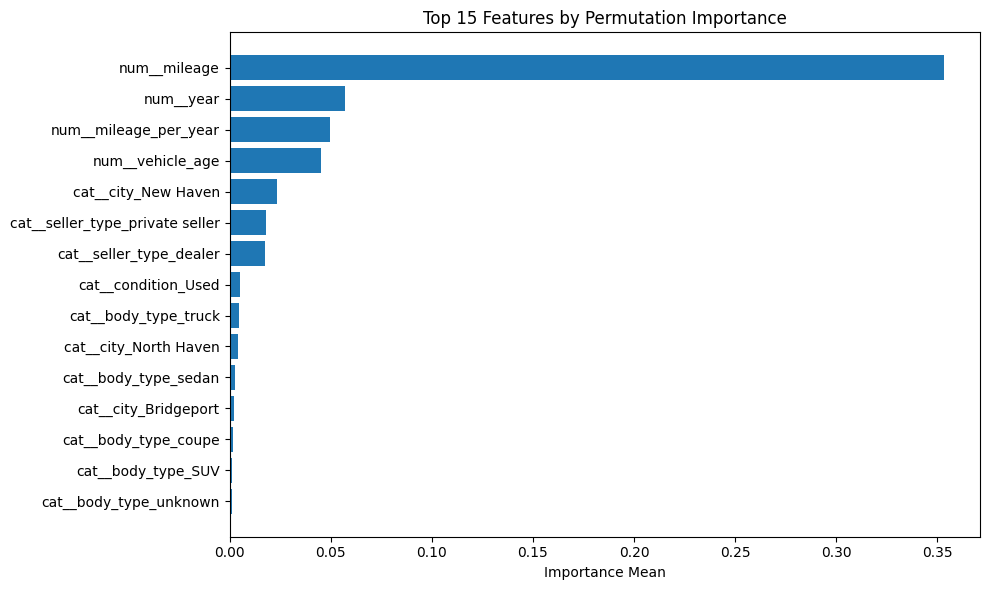

In [10]:
top15 = importance.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["importance_mean"])
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Importance Mean")
plt.tight_layout()
plt.show()

#Display PDPs

Showing: artifacts/pdp/pdp_mileage.png


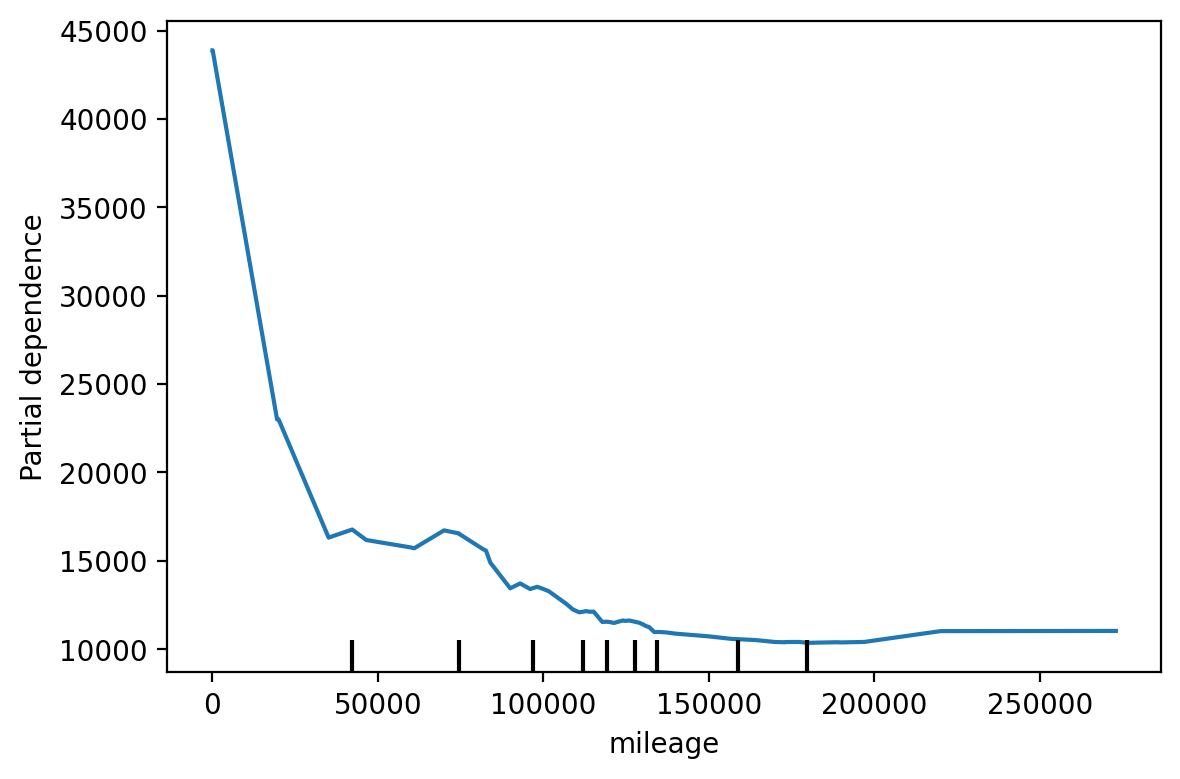

Showing: artifacts/pdp/pdp_vehicle_age.png


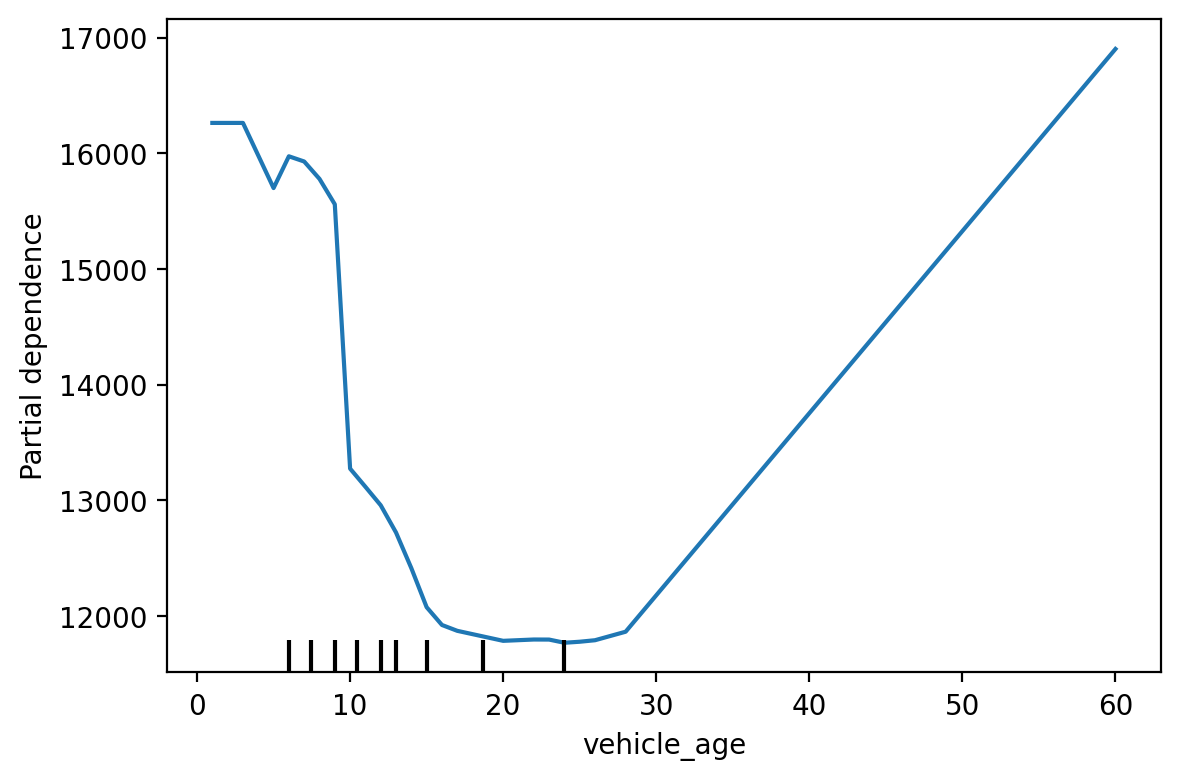

Showing: artifacts/pdp/pdp_year.png


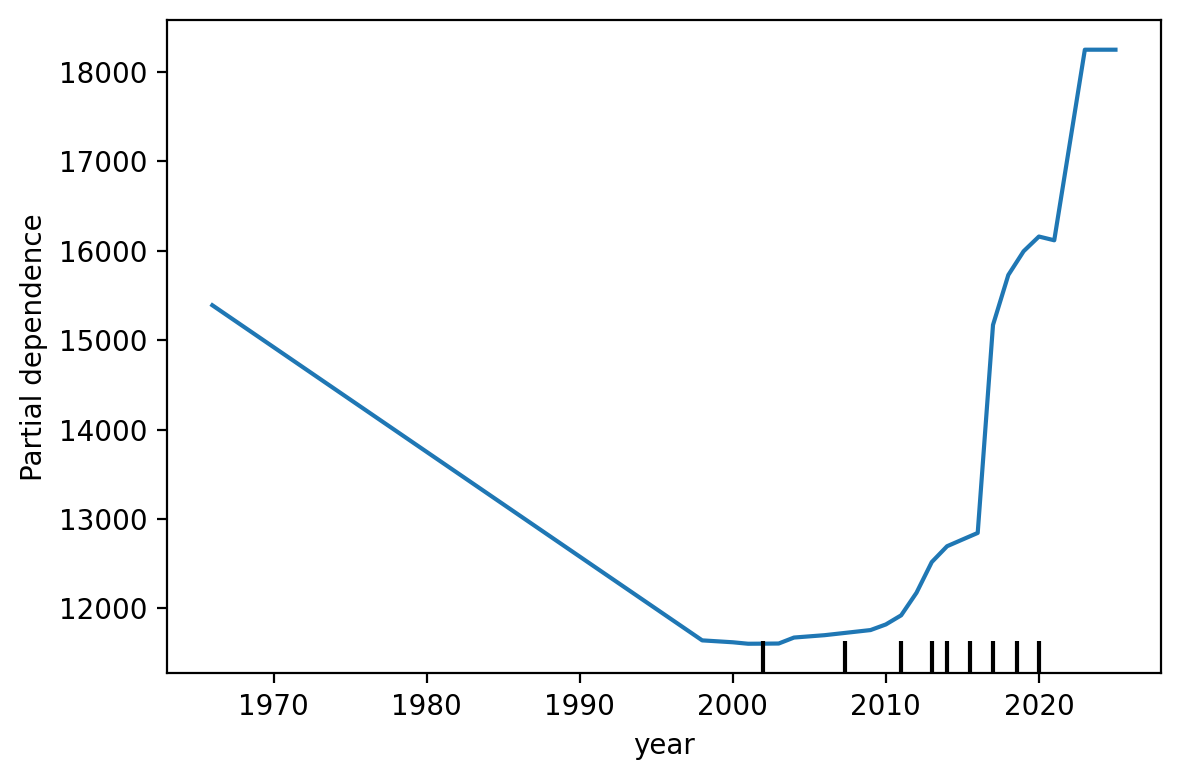

In [11]:
pdp_files = [
    "artifacts/pdp/pdp_mileage.png",
    "artifacts/pdp/pdp_vehicle_age.png",
    "artifacts/pdp/pdp_year.png",
]

for path in pdp_files:
    print("Showing:", path)
    display(Image(filename=path))

#Dashboard Summary

In [13]:
# This gives a quick readout of the latest model state.

latest = history.iloc[-1]

print("Latest Dashboard Summary:")
print(f"Rows used: {latest['n_rows']}")
print(f"MAE: {latest['mae']:.2f}")
print(f"RMSE: {latest['rmse']:.2f}")
print(f"MAPE: {latest['mape']:.4f}")
print(f"Bias: {latest['bias']:.2f}")
print()
print("Interpretation ideas:")
print("- Lower MAE/RMSE over time would suggest the model is improving as more data is added.")
print("- Bias near zero suggests the model is not strongly overpricing or underpricing on average.")
print("- Permutation importance shows which inputs matter most for price prediction.")
print("- PDPs show how the model responds to changes in major features like mileage, vehicle age, and year.")

Latest Dashboard Summary:
Rows used: 464
MAE: 5613.04
RMSE: 14678.36
MAPE: 0.4522
Bias: -3624.11

Interpretation ideas:
- Lower MAE/RMSE over time would suggest the model is improving as more data is added.
- Bias near zero suggests the model is not strongly overpricing or underpricing on average.
- Permutation importance shows which inputs matter most for price prediction.
- PDPs show how the model responds to changes in major features like mileage, vehicle age, and year.
